# 518880 Microstructure

展示内容：
- 1 tick / 2 tick spread 占比
- 每秒成交额分布
- 每秒 mid price 变化分布
- 盘口深度与盘口深度变化分布
- 不同时间段成交活跃度


In [ ]:
from IPython.display import Markdown, display
import pandas as pd

from analyze import run, save_tables, plot_overview

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')

df, tables = run()
save_tables(tables)

headline = tables['headline'].iloc[0]
activity = tables['activity'].sort_values('turnover_sum', ascending=False).reset_index(drop=True)
top_bucket = activity.iloc[0]
second_bucket = activity.iloc[1]
display(Markdown(
    f"""
## 样本范围
- 有效交易日: `{int(headline['trade_days'])}`
- snapshot 数: `{int(headline['snapshots'])}`
- 日期区间: `{df['trade_ymd'].min()}` 到 `{df['trade_ymd'].max()}`
- 1 tick spread 占比: `{headline['one_tick_spread_ratio']:.2%}`
- 2 tick spread 占比: `{headline['two_tick_spread_ratio']:.2%}`
- 每秒成交额均值 / 中位数: `{headline['avg_turnover_per_sec']:,.0f}` / `{headline['median_turnover_per_sec']:,.0f}`
- mid 不变占比: `{headline['mid_unchanged_ratio']:.2%}`
- 五档总深度均值: `{headline['avg_l5_depth']:,.0f}`
- 五档总深度绝对变化均值: `{headline['avg_abs_l5_depth_change']:,.0f}`

## 总结
- **流动性**: `518880` 以 `1 tick spread` 为主，`1 tick + 2 tick` 合计约 `{headline['one_tick_spread_ratio'] + headline['two_tick_spread_ratio']:.2%}`，整体是窄价差、高流动性的 ETF。
- **成交分布**: 每秒成交额均值明显高于中位数，说明分布右偏，少量大成交秒对总体成交额贡献很大。
- **价格与盘口**: `mid` 有 `{headline['mid_unchanged_ratio']:.2%}` 的时间不变，但五档深度均值约 `{headline['avg_l5_depth']:,.0f}`，且每秒绝对变化均值约 `{headline['avg_abs_l5_depth_change']:,.0f}`，说明价格黏住时盘口仍在频繁换手。
- **时段活跃度**: 最活跃时段是 `{top_bucket['bucket_30m']}`，成交额占比 `{top_bucket['turnover_share']:.2%}`；其次是 `{second_bucket['bucket_30m']}`。开盘最强，午后尾盘再抬升。
- **策略含义**: 对 `518880` 做秒级研究时，spread 本身可挖空间有限，更值得关注盘口深度变化、成交强弱和分时段条件。
"""
))



## 样本范围
- 有效交易日: `49`
- snapshot 数: `705380`
- 日期区间: `20251201` 到 `20260423`
- 1 tick spread 占比: `92.64%`
- 2 tick spread 占比: `6.47%`
- 每秒成交额均值 / 中位数: `513,855` / `123,262`
- mid 不变占比: `77.36%`
- 五档总深度均值: `3,583,478`
- 五档总深度绝对变化均值: `188,755`

## 总结
- **流动性**: `518880` 以 `1 tick spread` 为主，`1 tick + 2 tick` 合计约 `99.11%`，整体是窄价差、高流动性的 ETF。
- **成交分布**: 每秒成交额均值明显高于中位数，说明分布右偏，少量大成交秒对总体成交额贡献很大。
- **价格与盘口**: `mid` 有 `77.36%` 的时间不变，但五档深度均值约 `3,583,478`，且每秒绝对变化均值约 `188,755`，说明价格黏住时盘口仍在频繁换手。
- **时段活跃度**: 最活跃时段是 `09:30-10:00`，成交额占比 `23.55%`；其次是 `14:30-15:00`。开盘最强，午后尾盘再抬升。
- **策略含义**: 对 `518880` 做秒级研究时，spread 本身可挖空间有限，更值得关注盘口深度变化、成交强弱和分时段条件。


In [ ]:
display(Markdown('## Spread 分布'))
display(tables['spread'].head(10))

display(Markdown('## 每秒成交额摘要'))
display(tables['turnover'])

display(Markdown('## 每秒 Mid Price 变化摘要'))
display(tables['mid'])

display(Markdown('## 盘口深度摘要'))
display(tables['depth'])

display(Markdown('## 盘口深度变化摘要'))
display(tables['depth_change'])

display(Markdown('## 分时成交活跃度'))
display(tables['activity'].sort_values('turnover_sum', ascending=False).reset_index(drop=True))


## Spread 分布

,spread_ticks,ratio
0,1,0.924505
1,2,0.0658367
2,3,0.00704801
3,4,0.00151412
4,5,0.000456289
5,6,0.00017999
6,7,0.000104204
7,8,6.94697e-05
8,9,3.94714e-05
9,10,5.05234e-05


## 每秒成交额摘要

,turnover
q00,0
q25,"28,046.8"
q50,"135,754"
q75,"532,709"
q90,1.41566e+06
q95,2.33877e+06
q99,5.36375e+06
q100,5.20814e+08
mean,"540,033"
std,1.87087e+06


## 每秒 Mid Price 变化摘要

...

,l1_depth,l5_depth
q00,200,"61,900"
q25,"161,200",2.37254e+06
q50,"308,300",3.2885e+06
q75,"542,300",4.5716e+06
q90,"844,800",5.86654e+06
q99,1.71226e+06,8.92953e+06
q100,1.08334e+07,1.87577e+07
mean,"409,287",3.58773e+06
std,"390,192",1.72374e+06


## 盘口深度变化摘要

,l1_depth_change,l5_depth_change
q01,"-595,100","-937,531"
q05,"-264,300","-455,300"
q25,"-49,300","-106,100"
q50,-300,"1,300"
q75,"50,100","110,375"
q95,"260,155","440,900"
q99,"597,500","919,000"
mean,-22.0675,-18.4186
std,"210,206","330,348"
abs_mean,"105,224","189,545"


## 分时成交活跃度

,bucket_30m,seconds,turnover_sum,avg_turnover_per_sec,median_turnover_per_sec,avg_trade_count_per_sec,active_second_ratio,avg_trade_volume_per_sec,turnover_share
0,09:30-10:00,79200,8.05422e+10,1.01695e+06,"366,528",25.6027,0.98774,"100,000",0.235476
1,14:30-15:00,78882,4.62237e+10,"585,985","205,213",15.5001,0.976661,"57,908.8",0.135141
2,13:30-14:00,79200,4.29971e+10,"542,893","143,142",12.1064,0.938018,"53,922.8",0.125708
3,10:00-10:30,79200,4.02687e+10,"508,443","125,418",12.0449,0.949949,"49,885.9",0.117731
4,14:00-14:30,79200,3.8925e+10,"491,478","121,308",11.114,0.932323,"48,609.7",0.113802
5,10:30-11:00,79200,3.60387e+10,"455,034","104,098",10.3335,0.928333,"44,982.2",0.105364
6,11:00-11:30,79200,2.96597e+10,"374,492","72,980.9",8.45121,0.895126,"37,126.8",0.0867141
7,13:00-13:30,79200,2.73659e+10,"345,528","77,274.5",9.20727,0.911566,"34,187.7",0.0800076
8,15:00-15:30,44,1.2269e+07,"278,842","185,296",15.4545,1,"27,422.7",3.58701e-05
9,11:30-12:00,44,7.31766e+06,"166,310","37,217.9",5.63636,0.977273,"16,247.7",2.13941e-05


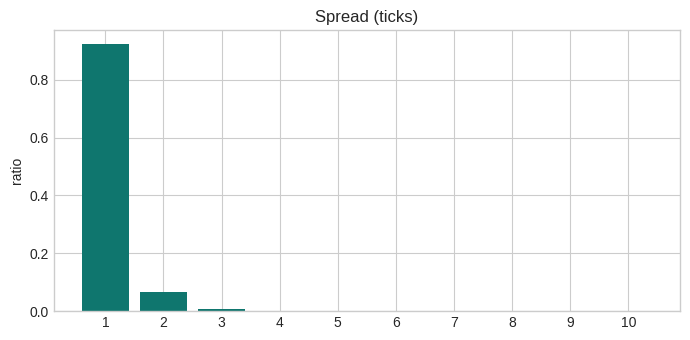

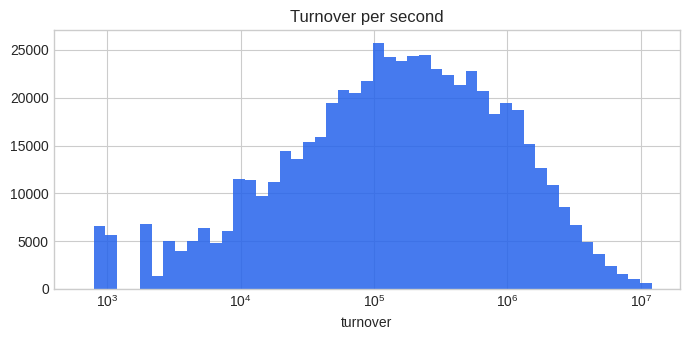

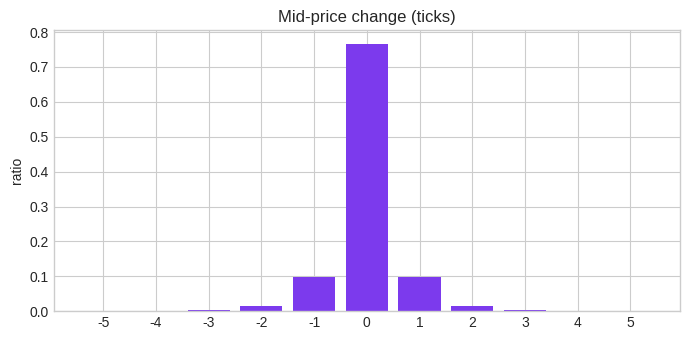

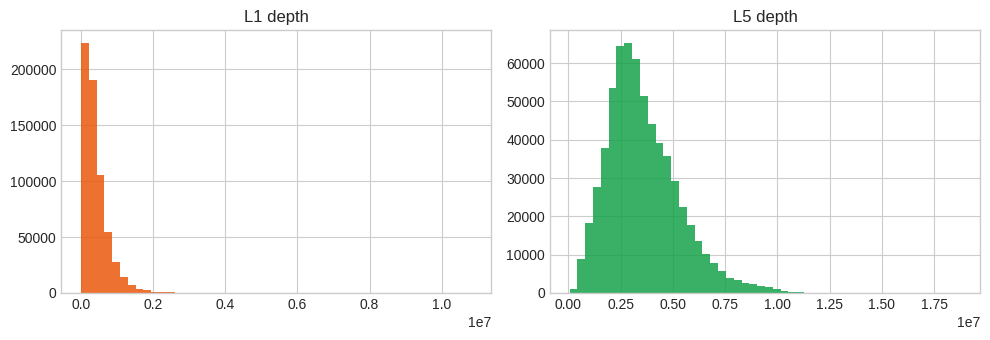

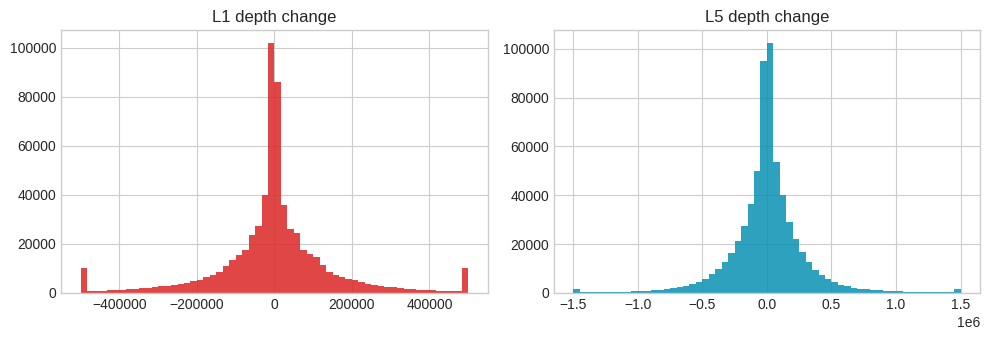

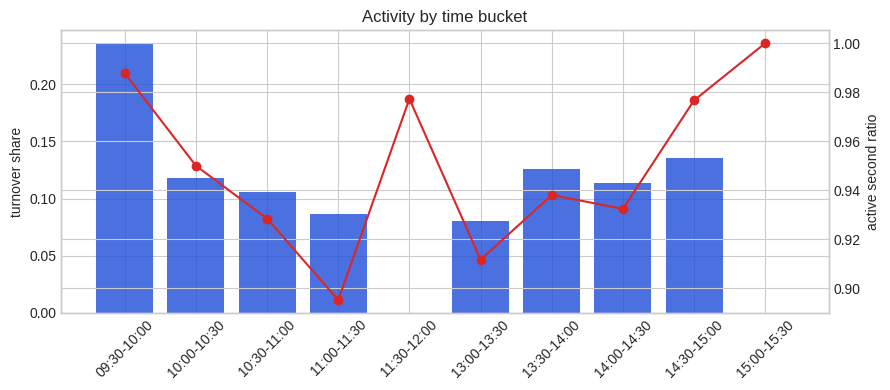

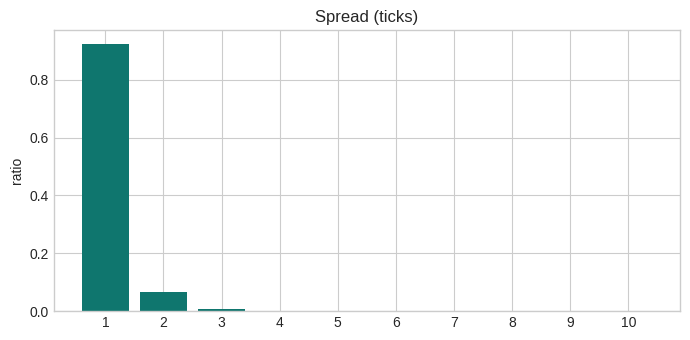

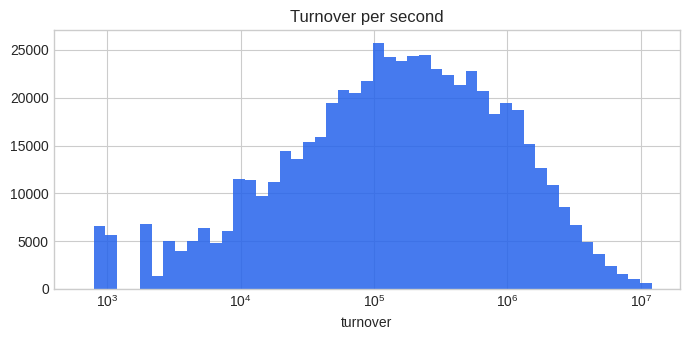

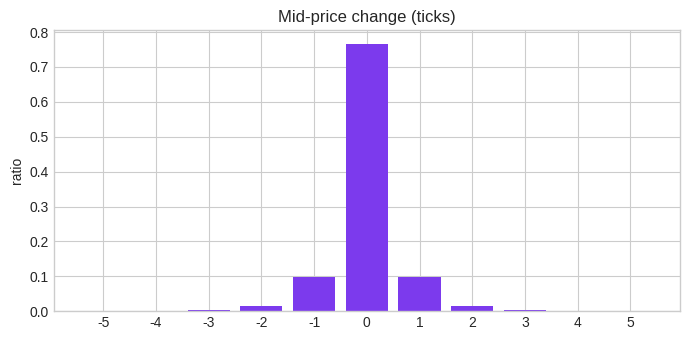

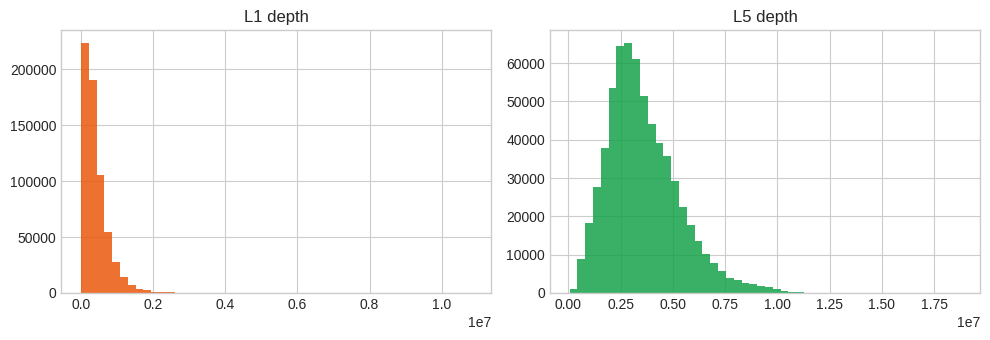

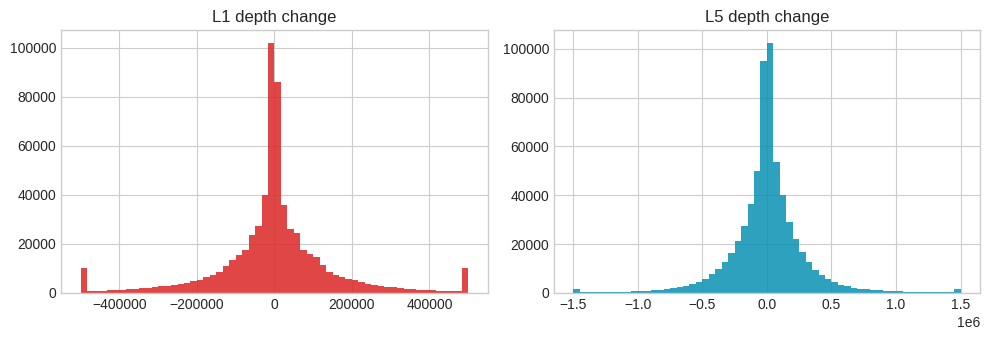

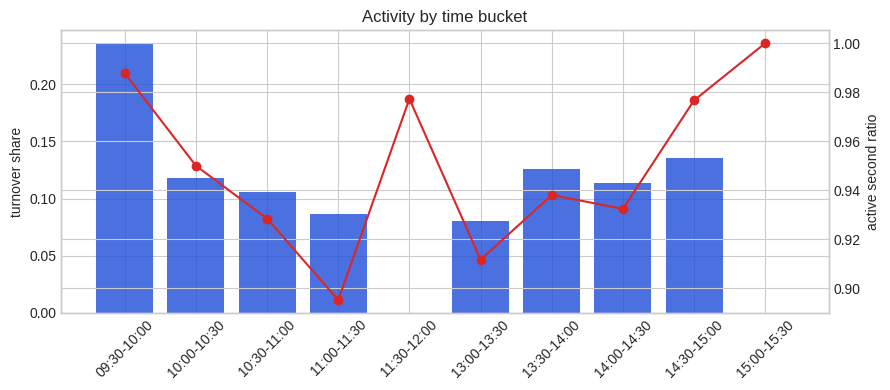

In [ ]:
figs = plot_overview(df, tables)
for fig in figs:
    fig.tight_layout()
    display(fig)
